## Construção do Modelo

### Importando as Bibliotecas

In [16]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_curve, roc_auc_score

### Importando o dataset

In [12]:
df_ml = pd.read_csv("../data/processed/ml_dataset.csv", sep=";")
df_ml.shape

(1985, 53)

### Definindo as Features, X e y

In [13]:
features = ['ida', 'ieg', 'ips', 'ipp', 'iaa']
X = df_ml[features]
y = df_ml['risco_futuro']

### Separação em Treino e Teste (80% treino, 20% teste)

In [14]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

### Treino do Modelos

In [15]:

# Modelo 1: Regressão Logística
log_reg = LogisticRegression(random_state=42, class_weight='balanced')
log_reg.fit(X_train, y_train)

# Modelo 2: Random Forest
rf_clf = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
rf_clf.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', random_state=42)

### Avaliação dos Modelos

In [18]:
# Prevendo as probabilidades para a Curva ROC
y_prob_log = log_reg.predict_proba(X_test)[:, 1]
y_prob_rf = rf_clf.predict_proba(X_test)[:, 1]

# Calculando a Área Sob a Curva (AUC - quanto mais perto de 1, melhor)
auc_log = roc_auc_score(y_test, y_prob_log)
auc_rf = roc_auc_score(y_test, y_prob_rf)

### Comparação entre Modelos

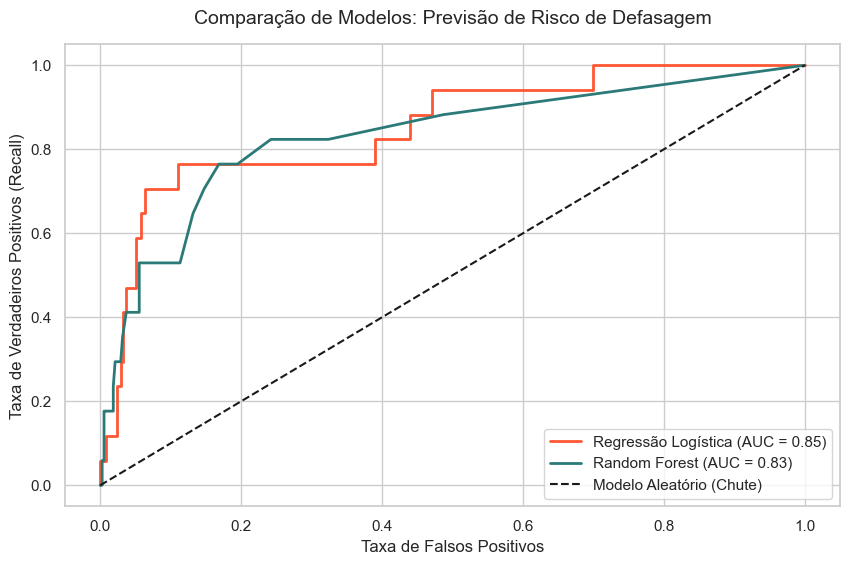

In [19]:
# Gerando os dados para plotar a curva
fpr_log, tpr_log, _ = roc_curve(y_test, y_prob_log)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)


# --- PLOTANDO A COMPARAÇÃO (CURVA ROC) ---
plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")

plt.plot(fpr_log, tpr_log, label=f'Regressão Logística (AUC = {auc_log:.2f})', color='#FF5733', linewidth=2)
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {auc_rf:.2f})', color='#2B7A78', linewidth=2)
plt.plot([0, 1], [0, 1], 'k--', label='Modelo Aleatório (Chute)')

plt.title('Comparação de Modelos: Previsão de Risco de Defasagem', fontsize=14, pad=15)
plt.xlabel('Taxa de Falsos Positivos', fontsize=12)
plt.ylabel('Taxa de Verdadeiros Positivos (Recall)', fontsize=12)
plt.legend(loc='lower right')
plt.show()

### Relatório Detalhado dos Modelos

In [20]:
print("--- Relatório da Regressão Logística ---")
print(classification_report(y_test, log_reg.predict(X_test)))

print("--- Relatório do Random Forest ---")
print(classification_report(y_test, rf_clf.predict(X_test)))

--- Relatório da Regressão Logística ---
              precision    recall  f1-score   support

           0       0.99      0.78      0.87       380
           1       0.13      0.76      0.23        17

    accuracy                           0.78       397
   macro avg       0.56      0.77      0.55       397
weighted avg       0.95      0.78      0.84       397

--- Relatório do Random Forest ---
              precision    recall  f1-score   support

           0       0.96      0.99      0.98       380
           1       0.50      0.12      0.19        17

    accuracy                           0.96       397
   macro avg       0.73      0.56      0.58       397
weighted avg       0.94      0.96      0.94       397



### Escolha do Modelo Definitivo

Na escolha do modelo preditivo, priorizamos o impacto social sobre a precisão matemática absoluta. Optamos pelo modelo de Regressão Logística (AUC = 0.85) em detrimento do Random Forest. Embora o Random Forest apresentasse 96% de acurácia geral, ele falhava em identificar os alunos em risco (Recall de 12%). A Regressão Logística, com um Recall de 76% para a classe de risco, atua como um verdadeiro sistema de 'Early Warning' (Alerta Precoce), permitindo que a Passos Mágicos intervenha a tempo, preferindo pecar pelo excesso de cuidado do que pela omissão.

### Criação do Modelo Treinado

In [ ]:
import joblib

# Exportando o modelo treinado de Regressão Logística
joblib.dump(
    log_reg,
    "../models/modelo_risco_passos_magicos.pkl"
)

print("Modelo salvo com sucesso na sua máquina!")